Nome: Letícia Lopes Mendes da Silva

RA: 184423

Curso: Eng. de Computação



# Ex05 - Classificação de imagens usando rede neural convolucional (CNN)

O objetivo principal deste notebook é ilustrar e praticar o uso de redes neurais convolucionais (CNNs) para tarefas de classificação de imagens. Em relação às redes neurais convencionais, as CNNs geralmente apresentam a vantagem de possuir menos parâmetros a serem aprendidos. Além disso, as CNNs são particularmente adequadas para trabalhar com imagens devido à sua arquitetura projetada para lidar com dados espaciais de forma eficiente.

Tomaremos como base a biblioteca PyTorch, que segue uma abordagem de programação orientada a objetos. Além dela, recomendamos o uso de outras bibliotecas relacionadas (como o PyTorch Lightning) que auxiliam e simplificam etapas do framework. Note que algumas destas bibliotecas podem não estar disponíveis por padrão no Colab ou sua máquina, sendo necessária sua instalação (como exemplificado na próxima célula de código).

Para mais informações sobre redes convolucionais, exemplos e boas práticas, recomendamos os materiais de apoio às aulas 5 e 6 disponibilizados no classroom. Lá você vai encontrar um tutorial teórico sobre CNN, além de tutoriais práticos disponibilizados no GitHub, vídeos e links de apoio. Em especial, o tutorial prático de classificação com CNN ([link](https://colab.research.google.com/drive/1uXLYbWwHT8cChAYmexV6QNUi5eI4ITod?usp=sharing)) pode ser de grande ajuda.

**Atenção!** Não se esqueça de utilizar a GPU do Colab (clique em "Ambiente de execução" e "Alterar o tipo de ambiente de execução", selecione a GPU).

In [1]:
# Instalando bibliotecas
!pip install pytorch-lightning torchinfo torchmetrics torch-summary torchmetrics medmnist tensorboard

In [2]:
# Importando as bibliotecas que serão utilizadas
import multiprocessing as mp
import os
import random
import sys
from glob import glob

import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torchinfo
from medmnist import DermaMNIST
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchmetrics import Accuracy
from torchsummary import summary
from torchvision import datasets, models
from torchvision import transforms
from torchvision.utils import make_grid
import torchvision.transforms.functional as F

%load_ext tensorboard

In [3]:
torch.set_float32_matmul_precision('medium')

## Parte 1 - Exemplo de classificação com o MNIST

Exemplificaremos algumas das etapas do framework de classificação com CNN utilizando o conjunto de dados MNIST (Modified National Institute of Standards and Technology database), um grande conjunto de dados de dígitos manuscritos comumente usado na área de aprendizado de máquina. Ele consiste de 60.000 imagens de treinamento e 10.000 images de teste (que, no nosso exemplo, serão utilizadas para validação). As imagens do conjunto são de 28x28 pixels. Uma descrição completa do conjunto de dados pode ser encontrada [aqui](https://en.wikipedia.org/wiki/MNIST_database).

### Leitura dos dados

Idealmente, códigos para processar amostras de dados devem estar desacoplados do código do treinamento do modelo, facilitando sua legibilidade e modularidade. O PyTorch fornece duas primitivas de dados ([torch.utils.data.DataLoader](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) e [torch.utils.data.Dataset](https://pytorch.org/docs/stable/data.html#torch.utils.data.Dataset)) que facilitam a leitura, processamento e organização dos dados para entrada no modelo. Mais informações sobre Datasets e DataLoaders podem ser encontradas [aqui](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) e [aqui](https://blog.paperspace.com/dataloaders-abstractions-pytorch/).

In [4]:
# Carregando os dados utilizando torchvision.datasets e convertendo as imagens para tensores
training_data = datasets.MNIST(
    root="data_mnist",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)
val_data = datasets.MNIST(
    root="data_mnist",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(training_data)
print()
print(val_data)
print()
print("*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!")

Dataset MNIST
    Number of datapoints: 60000
    Root location: data_mnist
    Split: Train
    StandardTransform
Transform: ToTensor()

Dataset MNIST
    Number of datapoints: 10000
    Root location: data_mnist
    Split: Test
    StandardTransform
Transform: ToTensor()

*Note que, apesar de identificado como teste, utilizaremos o segundo conjunto de dados para validação!


**É sempre importante checar e visualizar os dados a cada etapa do framework de classificação, garantindo que eles estão de acordo com o esperado e evitando a propagação de erros.**

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 0
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


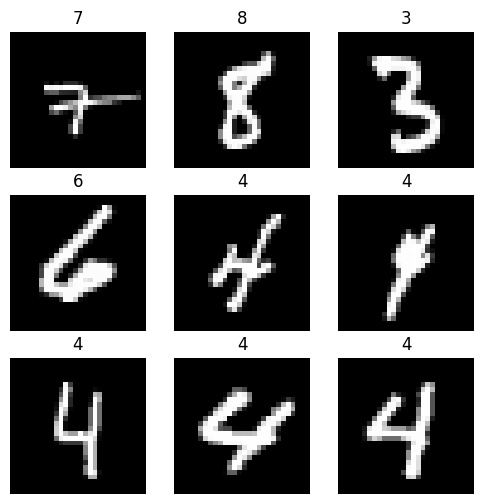

In [5]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(training_data)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print('Shape da imagem:', training_example[0].shape)
print('Label:', training_example[1])
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(training_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

2
<class 'torch.Tensor'> <class 'int'>
Shape da imagem: torch.Size([1, 28, 28])
Label: 2
Maior valor de intensidade da imagem: tensor(1.)
Menor valor de intensidade da imagem: tensor(0.)


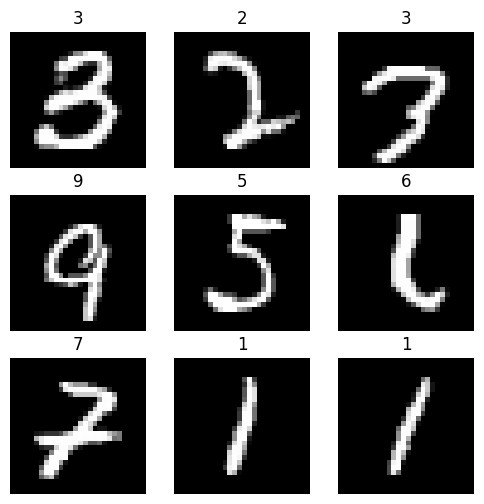

In [6]:
# Checando informações de uma amostra de validação
val_example = random.choice(val_data)
print(len(val_example))
print(type(val_example[0]), type(val_example[1]))
print('Shape da imagem:', val_example[0].shape)
print('Label:', val_example[1])
print('Maior valor de intensidade da imagem:', torch.max(val_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(val_example[0]))

# Visualizando algumas imagens e labels do conjunto de validação
figure = plt.figure(figsize=(6, 6))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(val_data)
    plt.subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
plt.show()

### Exercício 1.1

Explique o processamento aplicado pela classe torchvision.transforms.ToTensor às imagens do conjunto. Explique também porque foi necessário utilizar o .squeeze() para visualizar as imagens e qual a sua função.

RESPOSTA:

A classe `torchvision.transforms.ToTensor` converte a imagem de entrada, que normalmente está em formato PIL ou `numpy.ndarray`, para um tensor do PyTorch. Nesse processo, os valores dos pixels são convertidos para ponto flutuante e reescalados para o intervalo `[0, 1]`, além de reorganizar as dimensões para o formato `(C, H, W)`, em que `C` é o número de canais, `H` a altura e `W` a largura da imagem.

No caso do MNIST, as imagens são em escala de cinza, então o tensor fica com formato `(1, 28, 28)`. Segundo a documentação do matplotlib sobre a função [matplotlib.pyplot.imshow](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html), a função deve receber uma imagem X com a seguinte especificação:

```shell
X : array-like or PIL image. The image data. Supported array shapes are:

    - (M, N): an image with scalar data. The values are mapped to
        colors using normalization and a colormap. See parameters
        *norm*, *cmap*, *vmin*, *vmax*.
    - (M, N, 3): an image with RGB values (0-1 float or 0-255 int).
    - (M, N, 4): an image with RGBA values (0-1 float or 0-255 int),
        i.e. including transparency.

    The first two dimensions (M, N) define the rows and columns of
    the image.
```

Por isso, usamos `.squeeze()` para remover a dimensão unitária do canal e obter o formato `(28, 28)`, que pode ser exibido com `plt.imshow`. Essa justificativa vale para o MNIST pois ele contém imagens em preto e branco. Mas uma forma mais abrangente é usar `.permute(1, 2, 0)`, que reorganiza os eixos para o formato esperado, o que é útil quando a imagem tem múltiplos canais, como em RGB. Assim, o tensor `(1, 28, 28)` se tornaria `(28, 28, 1)`, e o matplotlib entenderia que se trata de uma imagem escalar.

### Hiperparâmetros

É interessante utilizar um dicionário de hiperparâmetros para organizar o código, evitar "números mágicos" e registrar as configurações de cada experimento realizado.

In [7]:
hparams = {"experiment_name": "Test_ResNet_1",  # experiment name identifies the run for later
           "max_epochs": 10,  # number of epochs to train
           "batch_size": 100,  # size of batch
           "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
           "nout": 10,  # number of classes
           "nin": 1,  # number of channels of the input image
           "lr": 1e-4,  # learning rate
           "wd": 1e-5,  # weight decay for optimizer
           "cpu": False,  # forces using the CPU
           }

for k, v in hparams.items():
    print(f"{k}: {v}")

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 16
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False


### Data Module

A classe [pytorch_lightning.LightningDataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html) pode ser utilizada para organizar os DataLoaders e os dados.

In [8]:
class MNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = training_data
        self.val = val_data

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

**Novamente, checamos os dados obtidos através do DataModule.**

Shape do batch: torch.Size([100, 1, 28, 28])


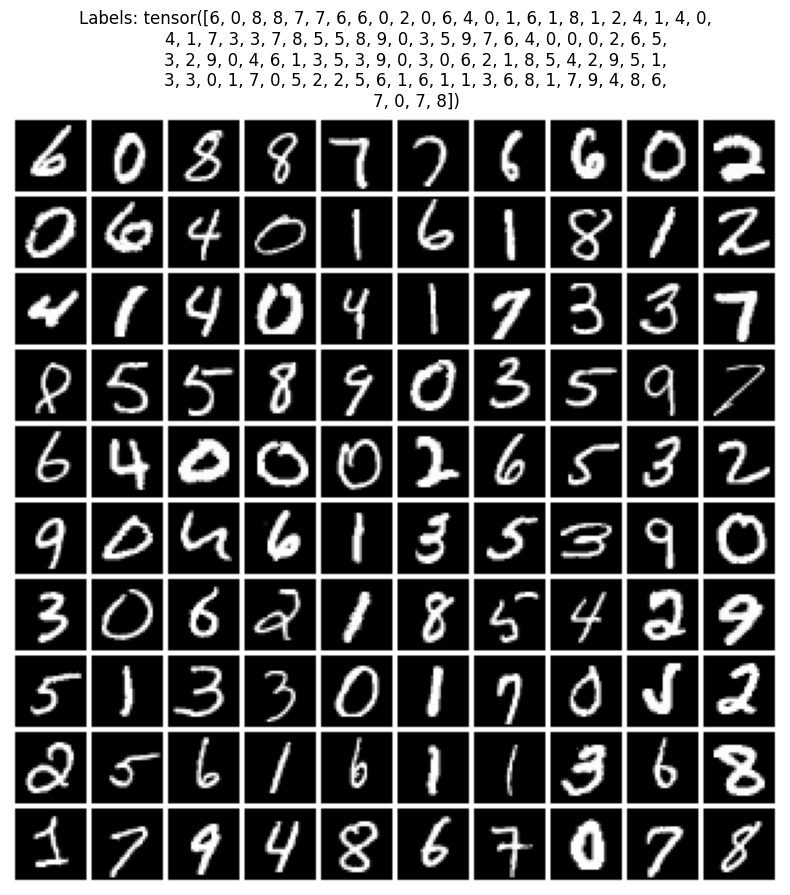

In [9]:
# DEBUG DATA MODULE
data_module = MNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

### Definindo a CNN

No código abaixo, é criado um modelo baseado na [Resnet-18](https://pytorch.org/vision/master/models/generated/torchvision.models.resnet18.html). O mesmo será treinado **sem transfer learning** e com uma inicialização randômica dos pesos. Visualizamos também todas as camadas (layers) que compõem o modelo e seus parâmetros.

In [10]:
cnn_model = models.resnet18(weights=None)
print(cnn_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
cnn_model.conv1 = nn.Conv2d(hparams['nin'], 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = cnn_model.fc.in_features
cnn_model.fc = nn.Linear(num_ftrs, hparams['nout'])
print(cnn_model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### Exercício 1.2

Para que serve cada camada da rede? Por que foi necessário modificar ligeiramente a rede (célula anterior) e que modificações foram realizadas?

RESPOSTA:

De modo geral, uma camada é uma transformação aplicada aos dados de entrada da rede. No modelo apresentado, cada componente como conv1, bn1, relu representa uma camada específica:

- `Conv2d` é uma camada convolucional, que extrai características da imagem, como bordas, texturas e outros padrões, por meio de filtros aprendíveis.
- `BatchNorm2d` aplica normalização para ajudar na estabilidade e na velocidade do treinamento.
- `ReLu` é uma função de ativação que introduz não linearidade, permitindo que a rede aprenda representações mais complexas.
- `MaxPool2d` é uma camada de pooling que reduz a dimensão espacial, preservando as informações mais relevantes.
- Os blocos residuais (layer1 a layer4) são conjuntos de camadas que aprendem representações cada vez mais abstratas dos dados.
- `AdaptiveAvgPool2d` é uma camada de pooling global, que reduz cada mapa de características em um único valor por canal
- Por fim, `Linear` é uma camada linear totalmente conectada, que transforma essas features finais no resultado da classificação.

Foi necessário adaptar a ResNet-18 pois a versão original foi criada para imagens RGB de 3 canais e para classificação em 1000 classes do ImageNet. Como o MNIST possui imagens em escala de cinza, com apenas 1 canal, a camada `conv1` precisou ser modificada para aceitar `nin = 1`. Além disso, a camada final `fc` foi trocada para produzir `nout = 10` saídas, correspondendo às 10 classes dos dígitos.

### Resumo do modelo

In [12]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model.to(device)
summary(cnn_model, (1, 28, 28));

cuda:0
Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 14, 14]          3,136
├─BatchNorm2d: 1-2                       [-1, 64, 14, 14]          128
├─ReLU: 1-3                              [-1, 64, 14, 14]          --
├─MaxPool2d: 1-4                         [-1, 64, 7, 7]            --
├─Sequential: 1-5                        [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-1                   [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-1                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-3                    [-1, 64, 7, 7]            --
|    |    └─Conv2d: 3-4                  [-1, 64, 7, 7]            36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 7, 7]            128
|    |    └─ReLU: 3-6                    [-1, 64, 7, 7]            --
|    └─BasicBlock: 2-2                   [-1, 64, 7, 7]         

### Exercício 1.3

Tente entender as dimensões da saída de cada camada da rede. Por exemplo, por que as três primeiras camadas possuem saídas com dimensões `(-1, 64, 14, 14)` e a quarta camada tem saída com dimensões `(-1, 64, 7, 7)`?

E quanto aos parâmetros a serem aprendidos, você consegue explicar como eles são calculados?

**RESPOSTA:**

As saídas das camadas seguem o formato:

```math
(\text{batch}, \text{canais}, \text{altura}, \text{largura}) = (B, C, H, W)
```

O valor `-1` representa o tamanho do batch, que pode variar de acordo com o `DataLoader`.

A mudança de dimensão acontece principalmente nas camadas convolucionais e de pooling. De acordo com a documentação do pytorch ([torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.conv.Conv2d.html) e [torch.nn.MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.pooling.MaxPool2d.html)), as dimensões $H_{out}$ e $W_{out}$ de saída são dadas por:

```math
\text{out} = \left\lfloor\frac{\text{in} + 2 \times \text{padding} - \text{dilation} \times (\text{kernel\_size} - 1) - 1}{\text{stride}} + 1\right\rfloor
```

Por padrão, `dilation = 1`.

No caso do MNIST, a entrada tem forma `(1, 28, 28)`:

- `conv1` usa $\text{kernel} = 7\times7$, $\text{stride} = 2$ e $\text{padding} = 3$, então reduz a resolução de $28\times28$ para $14\times14$ e produz 64 mapas: saída `(-1, 64, 14, 14)`.

```math
\text{out} = \left\lfloor\frac{28 + 2 \times 3 - (7 - 1) - 1}{2} + 1\right\rfloor = 14
```

- `bn1` e `relu` não alteram as dimensões, então a forma permanece `(-1, 64, 14, 14)`.
- `maxpool` usa $\text{kernel} = 3\times3$, $\text{stride} = 2$ e $\text{padding} = 1$, reduzindo de $14\times14$ para $7\times7$: saída `(-1, 64, 7, 7)`.

```math
\text{out} = \left\lfloor\frac{14 + 2 \times 1 - (3 - 1) - 1}{2} + 1\right\rfloor = 7
```

Reduções como essa acontecem ao longo da rede sempre que há convoluções com `stride > 1` ou operações de pooling.

---

Os parâmetros aprendíveis de uma rede neural correspondem aos *weights* (pesos) e *biases*, que são ajustados durante o treinamento por meio de algoritmos de otimização com base no gradiente de uma função de perda (*loss*). Esse gradiente é calculado via *backpropagation*, que aplica a regra da cadeia para propagar o erro da saída da rede até as camadas iniciais. A partir desses gradientes, algoritmos de otimização (como SGD, Adam ou AdamW) atualizam os parâmetros iterativamente a fim de minimizar a *loss*.

A forma de calcular os parâmetros depende da camada.

- **Camadas convolucionais ([torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.conv.Conv2d.html))**:

Como já vimos, nas camadas convolucionais, cada saída é obtida pela aplicação de filtros (kernels) sobre os canais de entrada. Cada filtro possui um conjunto de pesos que são aprendidos durante o treinamento. Esses pesos formam um tensor de dimensão:

```math
(C_{out}, \frac{C_{in}}{groups}, \text{kernel\_size}, \text{kernel\_size})
```

Se houver bias, ele adiciona mais $C_{out}$ parâmetros. Nas convoluções da ResNet, usa-se `groups = 1` e `bias = False`, pois o `BatchNorm2d` já introduz um deslocamento aprendível depois da convolução. Assim, o número de parâmetros de cada convolução é:

```math
C_{out} \times C_{in} \times \text{kernel\_size} \times \text{kernel\_size}
```

- **Camadas de normalização ([torch.nn.BatchNorm2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html#torch.nn.BatchNorm2d))**:

Nas camadas de normalização, são aprendidos dois parâmetros por canal de entrada: um fator de escala ($\gamma$) e um de deslocamento ($\beta$). Assim, cada camada possui $2 \times C_{in}$ parâmetros aprendíveis.

- **Camadas lineares ([torch.nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.modules.linear.Linear.html))**:

Nas camadas lineares, os parâmetros correspondem a uma matriz de pesos `W` e um vetor de bias `b`. Se a camada tiver `in_features = Nin` e `out_features = Nout`, então o total de parâmetros é:

```math
N_{out} \times N_{in} + N_{out}
```

- **Outras camadas:**
ReLU, pooling e outras operações não têm parâmetros ajustáveis, pois realizam apenas transformações fixas sobre os dados.

### Lightning Module

Aqui definimos o comportamento durante o treinamento, ou seja, o que acontece com um lote retornado pelo DataLoader.

In [13]:
class TrainMNIST(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = cnn_model
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x).softmax(dim=-1)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            _, preds = torch.max(y_hat, 1)
            self.accuracy(preds, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

### Treinando a CNN

In [14]:
debug = False  # Turn this True to test the code with a quick run

# Initialization
model = TrainMNIST(hparams)
data = MNISTDataModule(hparams)

# The PL trainer can run various callbacks during training. Here we only use the
# callback that saves the weights of the trained network.
os.makedirs("logs", exist_ok=True)
checkpoint_callback = [ModelCheckpoint(dirpath="logs",  # path to save checkpoint
                                       filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
                                       monitor="val_acc",
                                       mode="max")]

trainer = pl.Trainer(max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
                     fast_dev_run=debug,
                     callbacks=checkpoint_callback,
                     log_every_n_steps=1
                     )

print("Hyperparameters:\n")
for k, v in hparams.items():
    print(f'{k}: {v}')

trainer.fit(model, data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.701    Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode
0         Total Flops


Hyperparameters:

experiment_name: Test_ResNet_1
max_epochs: 10
batch_size: 100
nworkers: 16
nout: 10
nin: 1
lr: 0.0001
wd: 1e-05
cpu: False
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/ia901/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 9: 100%|██████████| 600/600 [00:10<00:00, 57.56it/s, v_num=0, val_loss=1.480, val_acc=0.986]

`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: 100%|██████████| 600/600 [00:10<00:00, 57.56it/s, v_num=0, val_loss=1.480, val_acc=0.986]


### Visualizando os logs de treinamento

Por padrão, o Pytorch Lightning registra os resultados do treinamento usando o TensorBoard. Você pode configurar muitos outros registradores (https://pytorch-lightning.readthedocs.io/en/stable/extensions/logging.html), recomendamos verificar o Neptune ou o MLFlow. Utilize esses registradores para comparar experimentos!

Abaixo é possível verificar os resultados do treinamento realizado previamente (disponibilizado no diretório **Dados/Ex05/saved_lightning_logs**).

In [15]:
%tensorboard --logdir lightning_logs

### Análise dos resultados

Após o treinamento da rede, é importante checar os resultados de validação, visualizando algumas saídas da rede e obtendo métricas de classificação. Abaixo exemplificamos a visualização da matriz de confusão.

In [16]:
# WARNING: This will load a random checkpoint from the logs folder, if you want an specific one change it!
# baseline_model = random.choice(glob("logs/*.ckpt"))

baseline_model = random.choice(glob("logs/Test_ResNet_1*.ckpt"))
print(f"Using model {baseline_model}")

# Load trained model
model = TrainMNIST.load_from_checkpoint(baseline_model).eval().cuda()

# Initialize validation data
data = MNISTDataModule(hparams)
data.setup()
data.hparams.batch_size = 1
val_data = data.val_dataloader()

def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

y_trues_val, y_labels_val = collect_2d_results(val_data, model)

Using model logs/Test_ResNet_1-epoch=5-val_acc=0.99.ckpt


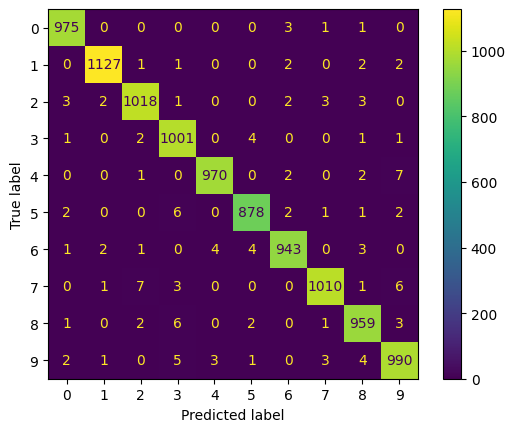

In [17]:
# Confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=np.arange(10)),
                                display_labels=np.arange(10))
fig = disp.plot(ax=None).figure_
plt.show()

Por fim, o modelo final seria avaliado em um conjunto de teste (que não está disponível no exemplo apresentado). **Vale ressaltar que o conjunto de teste não deve ser utilizado para refinar o modelo! Ele deve ser utilizado apenas para uma avaliação final do modelo.**

## Parte 2 - Classificação com o DermaMNIST

Vamos retomar a classificação do dataset de imagens dermatoscópicas de lesões de pele comuns, utilizado no Exercício 02. Desta vez, ao invés de extrair os atributos "artesanalmente" e classificar com o KNN, utilizaremos CNNs para realizar os dois processos simultaneamente (extração de atributos + classificação).

**Dataset**

O dataset consiste em 600 imagens de lesões de pele, obtidas ao longo de 20 anos em dois hospitais diferentes. Como as imagens foram obtidas e armazenadas de diferentes formas ao longo do tempo (armazenadas em arquivos PowerPoint, por exemplo), elas passaram por um processo de seleção, organização e padronização para compor o dataset. Assim, as imagens foram cortadas em torno das lesões de modo a deixá-las centralizadas e, em alguns casos, tiveram seus histogramas corrigidos manualmente para melhorar o contraste visual e a reprodução de cores.

As imagens estão divididas em dois tipos de lesão de pele:
- 300 casos de carcinoma basocelular (label 0) - um tipo de câncer de pele que começa nas células basais, raramente apresenta metástase, mas cresce de forma destrutiva se não tratado;
- 300 casos de melanoma (label 1) - o tipo mais grave de câncer de pele, que começa nas células produtoras de melanina, é quase sempre curável em estágios iniciais, mas tende a apresentar metástase com o tempo.

O dataset está separado em um conjunto de treino com 400 imagens (200 de cada classe), um conjunto de validação com 100 imagens (50 de cada classe) e um conjunto de teste com 100 imagens (50 de cada classe). As imagens devem ser classificadas em 0 ou 1, representando os dois tipos de lesões presentes no dataset (carcinoma ou melanoma, respectivamente).

### Exercício 2.1

Com base no exemplo apresentado e nos materiais de apoio disponibilizados, treine uma CNN para classificar as lesões de pele. Considere as recomendações abaixo:

- Considere aplicar [transformações](https://pytorch.org/vision/stable/transforms.html) durante a leitura dos dados, seja para normalizá-los ou realizar aumentação de dados.
- Lembre-se de sempre checar os dados!
- Você pode definir sua própria rede ou utilizar modelos de classificação disponibilizados pelo PyTorch (como a [ResNet](https://pytorch.org/vision/stable/models/resnet.html) ou a [EfficientNet](https://pytorch.org/vision/stable/models/efficientnet.html)). Caso utilize modelos disponibilizados, tome cuidado com as entradas e saídas da rede, talvez seja necessário realizar algumas modificações (como no exemplo apresentado). Considere também a utilização de modelos pré-treinados, eles apresentam resultados melhores do que modelos inicializados com pesos randômicos?
- Note que, no exemplo apresentado, os checkpoints da rede e os logs do PyTorch Lightning ficam salvos no ambiente de execução do Colab. Tome cuidado para não acabar perdendo experimentos! Você pode alterar o local em que esses arquivos são salvos para que sejam armazenados no seu Drive ou ainda salvar manualmente os arquivos que julgar importantes.
- Tente modificar os hiperparâmetros para obter melhores resultados de validação.
- Verifique os resultados do modelo: visualize algumas saídas da rede e obtenha métricas de classificação (acurácia, precisão, revocação e F1-score), além de imprimir a matriz de confusão.
- Idealmente, você deve avaliar apenas o modelo final no conjunto de teste.

Comente os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas. Compare também os resultados obtidos através da CNN com os resultados obtidos através do KNN no Exercício 02.

#### 2.1.2) Preparação dos Dados

In [18]:
image_size = 28

class_names = ["carcinoma basocelular", "melanoma"]
class_mapping = {
    0: "carcinoma basocelular", # label original: 1
    1: "melanoma"               # label original: 4
}

train_dataset_base = DermaMNIST(
    split="train",
    download=True,
    size=image_size
)

test_dataset_base = DermaMNIST(
    split="test",
    download=True,
    size=image_size
)

# Train+Val
train_indices_0 = train_dataset_base.labels == 1
train_indices_1 = train_dataset_base.labels == 4

train_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][:200]
train_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][:200]
train_imgs = np.vstack([train_imgs_0, train_imgs_1])

val_imgs_0 = train_dataset_base.imgs[train_indices_0.flatten(), :, :, :][200:250]
val_imgs_1 = train_dataset_base.imgs[train_indices_1.flatten(), :, :, :][200:250]
val_imgs = np.vstack([val_imgs_0, val_imgs_1])

# Test
test_indices_0 = test_dataset_base.labels == 1
test_indices_1 = test_dataset_base.labels == 4

test_imgs_0 = test_dataset_base.imgs[test_indices_0.flatten(), :, :, :][:50]
test_imgs_1 = test_dataset_base.imgs[test_indices_1.flatten(), :, :, :][:50]
test_imgs = np.vstack([test_imgs_0, test_imgs_1])

# Labels
train_labels = np.zeros(400)
train_labels[200:].fill(1)

val_labels = np.zeros(100)
val_labels[50:].fill(1)

test_labels = np.zeros(100)
test_labels[50:].fill(1)

# Formato dos dados
print(f"Train dataset: {train_imgs.shape}, {train_labels.shape}")
print(f"Validation dataset: {val_imgs.shape}, {val_labels.shape}")
print(f"Test dataset: {test_imgs.shape}, {test_labels.shape}")

# train_dataset = TensorDataset(torch.tensor(train_imgs), torch.tensor(train_labels))
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# val_dataset = TensorDataset(torch.tensor(val_imgs), torch.tensor(val_labels))
# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

# test_dataset = TensorDataset(torch.tensor(test_imgs), torch.tensor(test_labels))
# test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)



# # Datasets
# train_dataset = TensorDataset(
#     torch.tensor(train_imgs, dtype=torch.float32) / 255.0,
#     torch.tensor(train_labels, dtype=torch.int64)
# )
# val_dataset = TensorDataset(
#     torch.tensor(val_imgs, dtype=torch.float32) / 255.0,
#     torch.tensor(val_labels, dtype=torch.int64)
# )
# test_dataset = TensorDataset(
#     torch.tensor(test_imgs, dtype=torch.float32) / 255.0,
#     torch.tensor(test_labels, dtype=torch.int64)
# )
# print("Train dataset:", len(train_dataset))
# print("Validation dataset:", len(val_dataset))
# print("Test dataset:", len(test_dataset))
# print(train_dataset[0][0].shape, train_dataset[0][0].dtype, train_dataset[0][1].shape, train_dataset[0][1].dtype)
# print(val_dataset[0][0].shape, val_dataset[0][0].dtype, val_dataset[0][1].shape, val_dataset[0][1].dtype)
# print(test_dataset[0][0].shape, test_dataset[0][0].dtype, test_dataset[0][1].shape, test_dataset[0][1].dtype)

# # Dataloaders
# train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)

# val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, num_workers=0)

# test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=0)

Train dataset: (400, 28, 28, 3), (400,)
Validation dataset: (100, 28, 28, 3), (100,)
Test dataset: (100, 28, 28, 3), (100,)


In [47]:
standard_size = image_size

data_transforms = {
    'train': transforms.Compose([
        # Transformações geométricas
        transforms.RandomHorizontalFlip(p=0.5), # Flip horizontal
        transforms.RandomVerticalFlip(p=0.5),   # Flip vertical
        # Transformação de intensidade
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),  # Variação de cor/brilho
        transforms.ConvertImageDtype(torch.float32),    # Garante que as imagens sejam float32
    ]),
    'val': transforms.Compose([
        transforms.ConvertImageDtype(torch.float32)
    ]),
    'test': transforms.Compose([
        transforms.ConvertImageDtype(torch.float32)
    ])
}

class DermaMNISTBinaryDataset(Dataset):
    def __init__(self, split, transform=None):
        self.mode = split
        self.transform = transform
        self._load_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = torch.tensor(self.data[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.int64)
        if self.transform:
            img = self.transform(img)
        return img, label

    def _load_data(self):
        if self.mode == "train":
            self.data = train_imgs
            self.labels = train_labels
        elif self.mode == "val":
            self.data = val_imgs
            self.labels = val_labels
        elif self.mode == "test":
            self.data = test_imgs
            self.labels = test_labels
        else:
            raise ValueError(f"Invalid mode {self.mode}")
        # self.data = torch.tensor(self.data.transpose(0, 3, 1, 2))   # Convertendo para tensor com shape (N, C, H, W)
        # self.labels = torch.tensor(self.labels, dtype=torch.int64)  # Convertendo para tensor de inteiros
        self.data = self.data.transpose(0, 3, 1, 2)   # Convertendo para shape (N, C, H, W)
        

train_dataset = DermaMNISTBinaryDataset(split="train", transform=data_transforms["train"])
val_dataset   = DermaMNISTBinaryDataset(split="val",   transform=data_transforms["val"])
test_dataset  = DermaMNISTBinaryDataset(split="test",  transform=data_transforms["test"])

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_dataloader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_dataloader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train:", len(train_dataset), "Val:", len(val_dataset), "Test:", len(test_dataset))

Train: 400 Val: 100 Test: 100


2
<class 'torch.Tensor'> <class 'torch.Tensor'>
Imagem:
	Shape: torch.Size([3, 28, 28])
	Dtype: torch.float32
Label:
	Shape: torch.Size([])
	Dtype: torch.int64
	Valor: 1
Maior valor de intensidade da imagem: tensor(0.8784)
Menor valor de intensidade da imagem: tensor(0.2706)


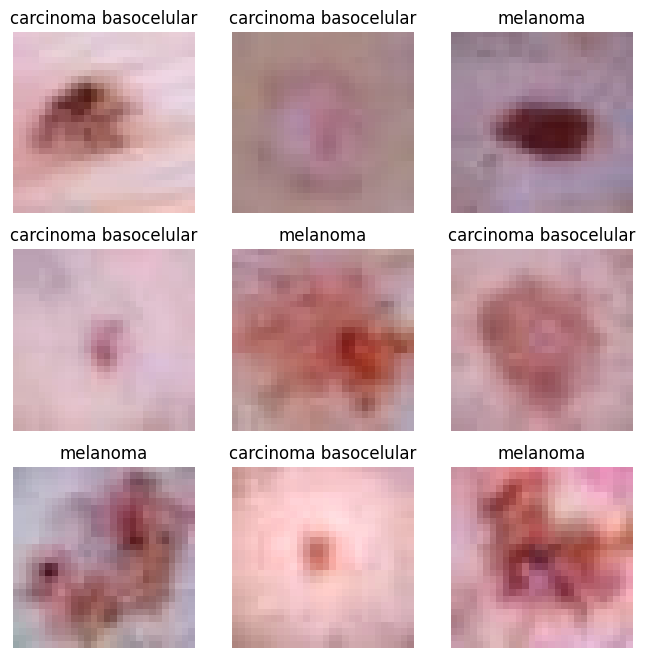

In [48]:
# Checando informações de uma amostra de treinamento
training_example = random.choice(train_dataset)
print(len(training_example))
print(type(training_example[0]), type(training_example[1]))
print("Imagem:")
print(f"\tShape: {training_example[0].shape}")
print(f"\tDtype: {training_example[0].dtype}")
print(f"Label:")
print(f"\tShape: {training_example[1].shape}")
print(f"\tDtype: {training_example[1].dtype}")
print(f"\tValor: {training_example[1].item()}")
print('Maior valor de intensidade da imagem:', torch.max(training_example[0]))
print('Menor valor de intensidade da imagem:', torch.min(training_example[0]))

# Visualizando algumas imagens e labels do conjunto de treinamento
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    img, label = random.choice(train_dataset)
    plt.subplot(rows, cols, i)
    plt.title(class_names[int(label)])
    plt.axis("off")
    # Convertendo o tensor para PIL Image para melhor visualização
    # A imagem é automaticamente convertida para uint8 e normalizada para o intervalo [0, 255]
    img_pil = F.to_pil_image(img, mode="RGB")
    plt.imshow(img_pil)
plt.show()

In [49]:
class DermaMNISTDataModule(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        if stage in ("fit", None):
            self.train = train_dataset
            self.val = val_dataset
        if stage in ("test", None):
            self.test = test_dataset

    '''
    Dataloaders optimize data loading and automatically prepare batches
    '''
    def train_dataloader(self):
        return DataLoader(self.train, 
                            batch_size=self.hparams.batch_size, 
                            num_workers=self.hparams.nworkers, 
                            shuffle=True,
                            persistent_workers=True,
                            pin_memory=True)

    def val_dataloader(self):
        return DataLoader(self.val, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

    def test_dataloader(self):
        return DataLoader(self.test, 
                          batch_size=self.hparams.batch_size, 
                          num_workers=self.hparams.nworkers, 
                          shuffle=False,
                          persistent_workers=True,
                          pin_memory=True)

Shape do batch: torch.Size([100, 3, 28, 28])
Shape do grid: torch.Size([3, 302, 302])


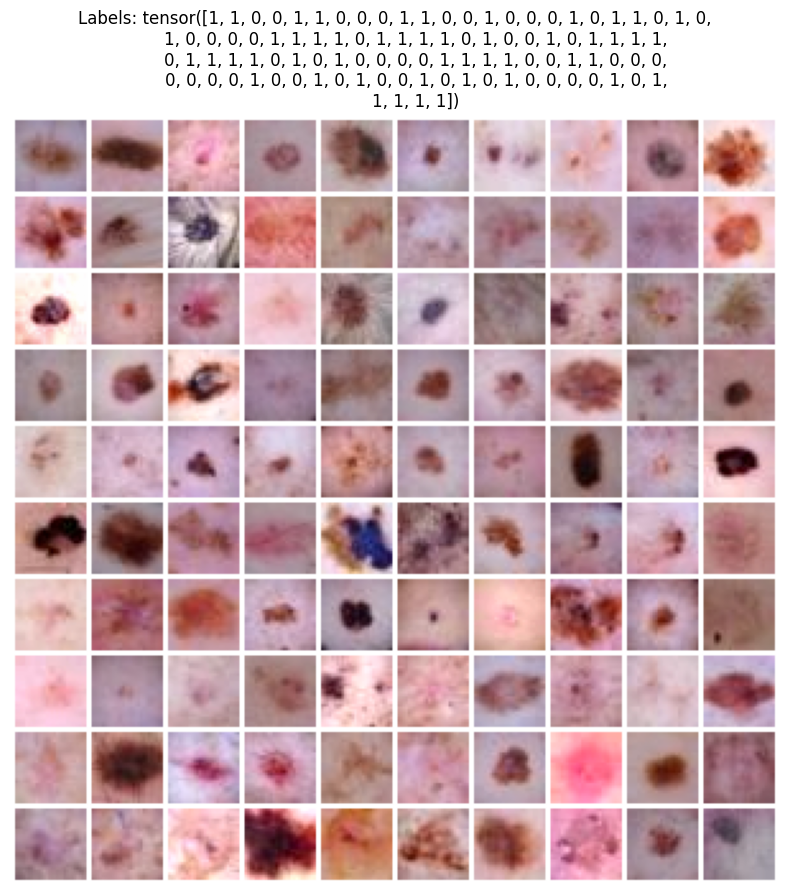

In [60]:
# DEBUG DATA MODULE
hparams = {
    "experiment_name": "Test_ResNet18_DermaMNIST",  # experiment name identifies the run for later
    "model_name": "resnet18",  # model architecture to use
    "max_epochs": 100,  # number of epochs to train
    "batch_size": 100,  # size of batch
    "nworkers": 0 if sys.platform.startswith("win") else mp.cpu_count(),  # number of workers to use in parallel loading
    "nout": 2,  # number of classes
    "nin": 3,  # number of channels of the input image
    "lr": 1e-4,  # learning rate
    "wd": 1e-5,  # weight decay for optimizer
    "cpu": False,  # forces using the CPU
}

data_module = DermaMNISTDataModule(hparams)
data_module.setup()

check_dataloader = data_module.train_dataloader()
img_batch, label_batch = next(iter(check_dataloader))
print("Shape do batch:", img_batch.shape)

img_grid = make_grid(img_batch, nrow=10, pad_value=1)
print("Shape do grid:", img_grid.shape)
fig = plt.figure(figsize=(10,10))
plt.imshow(img_grid.permute(1, 2, 0).numpy())
plt.title(f'Labels: {label_batch}')
plt.axis('off')
plt.show()

In [65]:
class DermaMNISTBinaryClassifier(pl.LightningModule):
    def __init__(self, hparams):
        super().__init__()

        self.save_hyperparameters(hparams)
        self.model = self.get_model()
        self.loss = nn.CrossEntropyLoss()
        self.accuracy = Accuracy(task="multiclass", num_classes=self.hparams.nout)

        torchinfo.summary(self.model)

    def forward(self, x):
        return self.model(x)

    def classification_step(self, mode, batch):
        x, y = batch
        y_hat = self.forward(x)
        loss = self.loss(y_hat, y)

        if mode == "train":
            self.log("loss", loss, on_epoch=True, on_step=True)
            return loss
        elif mode == "val":
            # _, preds = torch.max(y_hat, 1)
            # self.accuracy(preds, y)
            self.accuracy(y_hat, y)
            self.log("val_loss", loss, on_epoch=True, on_step=False, prog_bar=True)
            self.log("val_acc", self.accuracy, on_epoch=True, on_step=False, prog_bar=True)

    def training_step(self, train_batch, batch_idx):
        return self.classification_step("train", train_batch)

    def validation_step(self, val_batch, batch_idx):
        self.classification_step("val", val_batch)

    def configure_optimizers(self):
        optimizer = AdamW(self.model.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.wd)

        return optimizer

    def get_model(self):
        AVAILABLE_MODELS = {
            "resnet18": models.resnet18,
            "resnet50": models.resnet50,
            "resnet101": models.resnet101,
            "densenet121": models.densenet121,
            "densenet169": models.densenet169,
            "efficientnet_b0": models.efficientnet_b0,
            "efficientnet_b4": models.efficientnet_b4,
        }

        name = self.hparams.model_name
        if "resnet" in name:
            cnn = AVAILABLE_MODELS[name](weights=None)
            # Adaptando a primeira camada para o número de canais de entrada
            old_conv = cnn.conv1
            cnn.conv1 = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_conv.out_channels,
                kernel_size=old_conv.kernel_size,
                stride=old_conv.stride,
                padding=old_conv.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.fc.in_features
            cnn.fc = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        if "efficientnet" in name:
            cnn = AVAILABLE_MODELS[name](weights=None)
            # Adaptando a primeira camada para o número de canais de entrada
            old_features = cnn.features[0][0]
            cnn.features[0][0] = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_features.out_channels,
                kernel_size=old_features.kernel_size,
                stride=old_features.stride,
                padding=old_features.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.classifier[1].in_features
            cnn.classifier[1] = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        if "densenet" in name:
            cnn = AVAILABLE_MODELS[name](weights=None)
            # Adaptando a primeira camada para o número de canais de entrada
            old_features = cnn.features.conv0
            cnn.features.conv0 = nn.Conv2d(
                in_channels=self.hparams.nin,
                out_channels=old_features.out_channels,
                kernel_size=old_features.kernel_size,
                stride=old_features.stride,
                padding=old_features.padding,
                bias=False
            )
            # Adaptando a última camada para o número de classes de saída
            num_ftrs = cnn.classifier.in_features
            cnn.classifier = nn.Linear(num_ftrs, self.hparams.nout)
            return cnn

        else:
            raise ValueError(f"Model {name} not available")

In [67]:
def train_model(hparams, debug=False):
    # Initialization
    model = DermaMNISTBinaryClassifier(hparams)
    data = DermaMNISTDataModule(hparams)

    # The PL trainer can run various callbacks during training. Here we only use the
    # callback that saves the weights of the trained network.
    os.makedirs("logs", exist_ok=True)
    checkpoint_callback = ModelCheckpoint(
        dirpath="logs",  # path to save checkpoint
        filename=hparams["experiment_name"] + "-{epoch}-{val_acc:.2f}",
        monitor="val_acc",
        mode="max",
        verbose=True
    )

    # Early stopping callback to stop training if validation accuracy does not improve for 10 epochs
    # This is useful to prevent overfitting and save time during training
    early_stop_callback = EarlyStopping(
        monitor="val_acc",
        patience=10,
        mode="max",
        verbose=True
    )

    trainer = pl.Trainer(
        max_epochs=hparams["max_epochs"], #devices=1, accelerator="gpu",
        callbacks=[checkpoint_callback, early_stop_callback],
        log_every_n_steps=1,
        fast_dev_run=debug  # If debug=true, test the code with a quick run
    )

    print("Hyperparameters:\n")
    for k, v in hparams.items():
        print(f'{k}: {v}')

    summary(model, (hparams["nin"], image_size, image_size))

    trainer.fit(model, data)

In [30]:
train_model(hparams)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 11.2 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
11.2 M    Trainable params
0         Non-trainable params
11.2 M    Total params
44.710    Total estimated model params size (MB)
70        Modules in train mode
0         Modules in eval mode
0         Total Flops


Hyperparameters:

experiment_name: Test_ResNet18_DermaMNIST
model_name: resnet18
max_epochs: 100
batch_size: 100
nworkers: 16
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False
Layer (type:depth-idx)                   Output Shape              Param #
├─ResNet: 1-1                            [-1, 2]                   --
|    └─Conv2d: 2-1                       [-1, 64, 14, 14]          9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 14, 14]          128
|    └─ReLU: 2-3                         [-1, 64, 14, 14]          --
|    └─MaxPool2d: 2-4                    [-1, 64, 7, 7]            --
|    └─Sequential: 2-5                   [-1, 64, 7, 7]            --
|    |    └─BasicBlock: 3-1              [-1, 64, 7, 7]            73,984
|    |    └─BasicBlock: 3-2              [-1, 64, 7, 7]            73,984
|    └─Sequential: 2-6                   [-1, 128, 4, 4]           --
|    |    └─BasicBlock: 3-3              [-1, 128, 4, 4]           230,144
|    |    └─BasicBlock: 3-4        

Metric val_acc improved. New best score: 0.500
Epoch 0, global step 4: 'val_acc' reached 0.50000 (best 0.50000), saving model to '/home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs/Test_ResNet18_DermaMNIST-epoch=0-val_acc=0.50.ckpt' as top 1


Epoch 1: 100%|██████████| 4/4 [00:00<00:00, 33.54it/s, v_num=3, val_loss=0.693, val_acc=0.540]

Metric val_acc improved by 0.040 >= min_delta = 0.0. New best score: 0.540
Epoch 1, global step 8: 'val_acc' reached 0.54000 (best 0.54000), saving model to '/home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs/Test_ResNet18_DermaMNIST-epoch=1-val_acc=0.54.ckpt' as top 1


...

Epoch 23: 100%|██████████| 4/4 [00:00<00:00, 42.55it/s, v_num=3, val_loss=0.248, val_acc=0.900]

Epoch 23, global step 96: 'val_acc' was not in top 1


Epoch 24: 100%|██████████| 4/4 [00:00<00:00, 42.43it/s, v_num=3, val_loss=0.271, val_acc=0.900]

Monitored metric val_acc did not improve in the last 10 records. Best score: 0.900. Signaling Trainer to stop.
Epoch 24, global step 100: 'val_acc' was not in top 1


Epoch 24: 100%|██████████| 4/4 [00:00<00:00, 41.69it/s, v_num=3, val_loss=0.271, val_acc=0.900]


In [31]:
%tensorboard --logdir lightning_logs

Reusing TensorBoard on port 6006 (pid 73635), started 0:14:36 ago. (Use '!kill 73635' to kill it.)

In [ ]:
def collect_2d_results(data, model):
    y_trues = []
    y_labels = []
    for (img, label) in data:
        with torch.no_grad():
            out = model(img.cuda()).argmax(dim=-1).item()
        
        label = label.numpy()
        y_trues.append(label)
        y_labels.append(out)

    return y_trues, y_labels

def evaluate_model(ckpt_path):
    model = DermaMNISTBinaryClassifier.load_from_checkpoint(ckpt_path).eval().cuda()
    # Initialize test data
    data = DermaMNISTDataModule(hparams)
    data.setup()
    data.hparams.batch_size = 1
    test_data = data.test_dataloader()

    y_trues_val, y_labels_val = collect_2d_results(test_data, model)

    # Confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_trues_val, y_labels_val, labels=[0, 1]),
                                    display_labels=class_names)
    fig = disp.plot(ax=None).figure_
    plt.show()

    # Classification report
    print(classification_report(y_trues_val, y_labels_val, target_names=class_names))

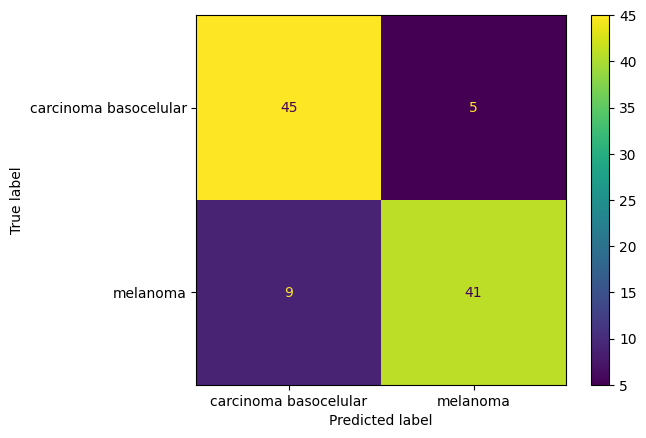

                       precision    recall  f1-score   support

carcinoma basocelular       0.83      0.90      0.87        50
             melanoma       0.89      0.82      0.85        50

             accuracy                           0.86       100
            macro avg       0.86      0.86      0.86       100
         weighted avg       0.86      0.86      0.86       100



In [42]:
baseline_model = "logs/Test_ResNet18_DermaMNIST-epoch=14-val_acc=0.90.ckpt"
evaluate_model(baseline_model)

In [35]:
hparams["experiment_name"] = "Test_ResNet50_DermaMNIST"
hparams["model_name"] = "resnet50"
train_model(hparams)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/ia901/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 23.5 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
23.5 M    Trainable params
0         Non-t

Hyperparameters:

experiment_name: Test_ResNet50_DermaMNIST
model_name: resnet50
max_epochs: 100
batch_size: 100
nworkers: 16
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False
Layer (type:depth-idx)                   Output Shape              Param #
├─ResNet: 1-1                            [-1, 2]                   --
|    └─Conv2d: 2-1                       [-1, 64, 14, 14]          9,408
|    └─BatchNorm2d: 2-2                  [-1, 64, 14, 14]          128
|    └─ReLU: 2-3                         [-1, 64, 14, 14]          --
|    └─MaxPool2d: 2-4                    [-1, 64, 7, 7]            --
|    └─Sequential: 2-5                   [-1, 256, 7, 7]           --
|    |    └─Bottleneck: 3-1              [-1, 256, 7, 7]           75,008
|    |    └─Bottleneck: 3-2              [-1, 256, 7, 7]           70,400
|    |    └─Bottleneck: 3-3              [-1, 256, 7, 7]           70,400
|    └─Sequential: 2-6                   [-1, 512, 4, 4]           --
|    |    └─Bottleneck: 3-4         

/home/leticialopes/miniconda3/envs/ia901/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 4/4 [00:00<00:00, 13.57it/s, v_num=4, val_loss=0.705, val_acc=0.500]

Metric val_acc improved. New best score: 0.500
Epoch 0, global step 4: 'val_acc' reached 0.50000 (best 0.50000), saving model to '/home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs/Test_ResNet50_DermaMNIST-epoch=0-val_acc=0.50.ckpt' as top 1


...

Epoch 42: 100%|██████████| 4/4 [00:00<00:00, 16.90it/s, v_num=4, val_loss=0.373, val_acc=0.810]

Epoch 42, global step 172: 'val_acc' was not in top 1


Epoch 43: 100%|██████████| 4/4 [00:00<00:00, 16.98it/s, v_num=4, val_loss=0.422, val_acc=0.740]

Monitored metric val_acc did not improve in the last 10 records. Best score: 0.860. Signaling Trainer to stop.
Epoch 43, global step 176: 'val_acc' was not in top 1


Epoch 43: 100%|██████████| 4/4 [00:00<00:00, 16.89it/s, v_num=4, val_loss=0.422, val_acc=0.740]


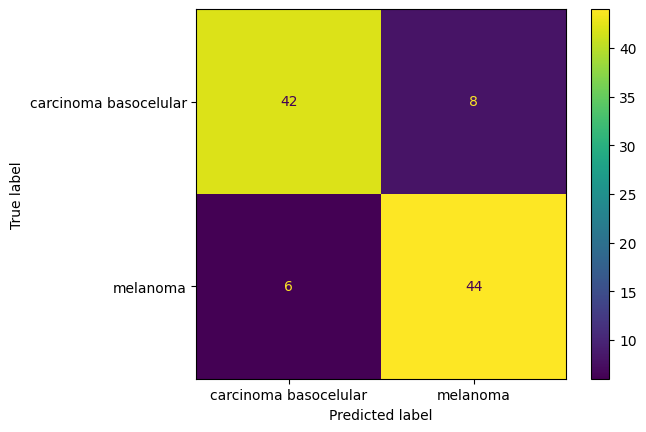

                       precision    recall  f1-score   support

carcinoma basocelular       0.88      0.84      0.86        50
             melanoma       0.85      0.88      0.86        50

             accuracy                           0.86       100
            macro avg       0.86      0.86      0.86       100
         weighted avg       0.86      0.86      0.86       100



In [36]:
baseline_model = "logs/Test_ResNet50_DermaMNIST-epoch=33-val_acc=0.86.ckpt"
evaluate_model(baseline_model)

In [66]:
hparams["experiment_name"] = "Test_ResNet101_DermaMNIST"
hparams["model_name"] = "resnet101"
train_model(hparams)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/leticialopes/miniconda3/envs/ia901/lib/python3.13/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name     | Type               | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | model    | ResNet             | 42.5 M | train | 0    
1 | loss     | CrossEntropyLoss   | 0      | train | 0    
2 | accuracy | MulticlassAccuracy | 0      | train | 0    
----------------------------------------------------------------
42.5 M    Trainable params
0         Non-t

Hyperparameters:

experiment_name: Test_ResNet101_DermaMNIST
model_name: resnet101
max_epochs: 100
batch_size: 100
nworkers: 16
nout: 2
nin: 3
lr: 0.0001
wd: 1e-05
cpu: False
Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/leticialopes/miniconda3/envs/ia901/lib/python3.13/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 0: 100%|██████████| 4/4 [00:00<00:00,  6.59it/s, v_num=10, val_loss=0.699, val_acc=0.500]

Metric val_acc improved. New best score: 0.500
Epoch 0, global step 4: 'val_acc' reached 0.50000 (best 0.50000), saving model to '/home/leticialopes/projects/IA901/2026s1-pi05-cnn-leticialopesms/logs/Test_ResNet101_DermaMNIST-epoch=0-val_acc=0.50.ckpt' as top 1


...

Epoch 38: 100%|██████████| 4/4 [00:00<00:00,  7.71it/s, v_num=10, val_loss=0.466, val_acc=0.780]

Epoch 38, global step 156: 'val_acc' was not in top 1


Epoch 39: 100%|██████████| 4/4 [00:00<00:00,  7.67it/s, v_num=10, val_loss=0.455, val_acc=0.760]

Monitored metric val_acc did not improve in the last 10 records. Best score: 0.820. Signaling Trainer to stop.
Epoch 39, global step 160: 'val_acc' was not in top 1


Epoch 39: 100%|██████████| 4/4 [00:00<00:00,  7.65it/s, v_num=10, val_loss=0.455, val_acc=0.760]


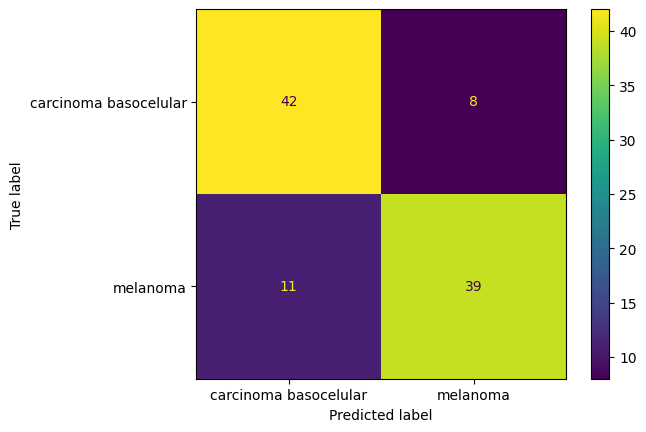

                       precision    recall  f1-score   support

carcinoma basocelular       0.79      0.84      0.82        50
             melanoma       0.83      0.78      0.80        50

             accuracy                           0.81       100
            macro avg       0.81      0.81      0.81       100
         weighted avg       0.81      0.81      0.81       100



In [68]:
baseline_model = "logs/Test_ResNet101_DermaMNIST-epoch=29-val_acc=0.82.ckpt"
evaluate_model(baseline_model)

## Parte 3 - Classificação com o DermaMNIST original (opcional para EA979)

### Exercício 3.1

Treine novamente o modelo final do exercício anterior, mas dessa vez utilize o conjunto original de dados do DermaMNIST (train_dataset_base, test_dataset_base).

**Note que o conjunto original de dados possui 7 classes distintas, mas estamos interessados apenas em duas classes: casos de carcinoma basocelular (label 1) e melanoma (label 4).** Portanto, você deve filtrar e organizar os dados para que eles sejam utilizados na classificação.

Verifique a quantidade de amostras de cada classe de interesse nos conjuntos de treino, validação e teste. Você deve notar que as duas classes estão desbalanceadas. Busque alternativas para lidar com esse desbalanceamento. Após aplicar as modificações os resultados da rede melhoraram?

Não se esqueça de comentar sobre os métodos utilizados e resultados obtidos, tentando justificar as decisões que foram tomadas.

In [70]:
# Seu código aqui